<a href="https://colab.research.google.com/github/regitaaft/iris-eda-ml/blob/main/tugasML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUGAS MACHINE LEARNING**

Regita Aftina Rizqi (2304010002)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
print("Jumlah data:", df.shape[0])
print("Jumlah variabel:", df.shape[1])

print("\nTipe data tiap variabel:")
print(df.dtypes)

print("\nJumlah masing-masing spesies:")
print(df['species'].value_counts())

Jumlah data: 150
Jumlah variabel: 5

Tipe data tiap variabel:
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Jumlah masing-masing spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:
stats = df.describe()
stats.loc[['mean', '50%', 'std', 'min', 'max']]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,5.843333,3.057333,3.758000,1.199333
50%,5.800000,3.000000,4.350000,1.300000
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000


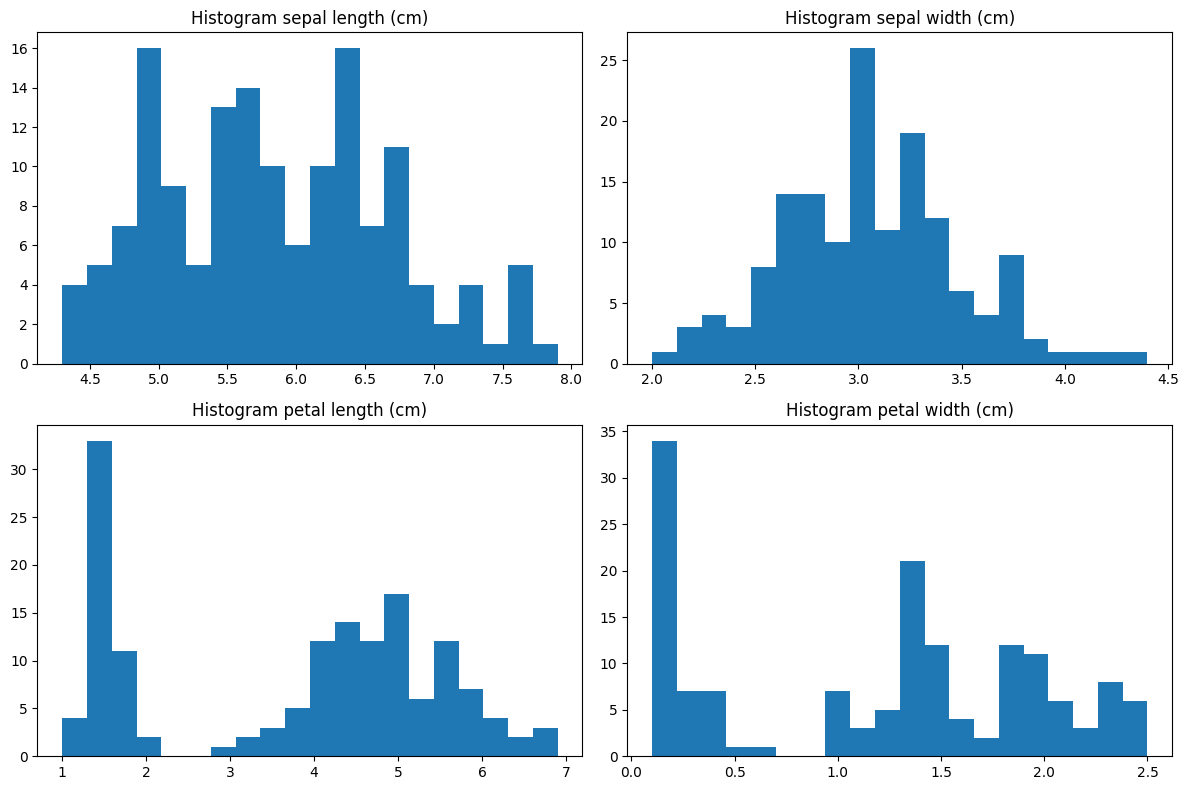

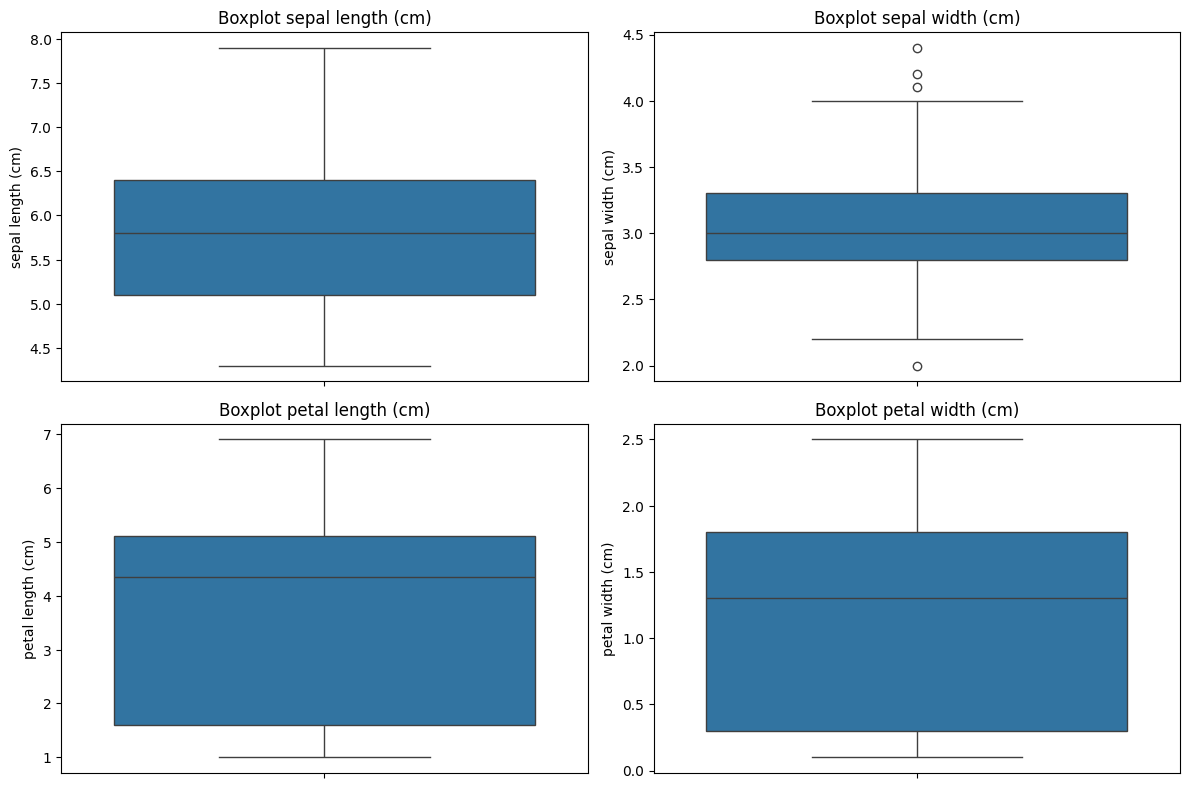

In [4]:
num_cols = iris.feature_names

# Histogram
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    plt.hist(df[col], bins=20)
    plt.title(f'Histogram {col}')
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

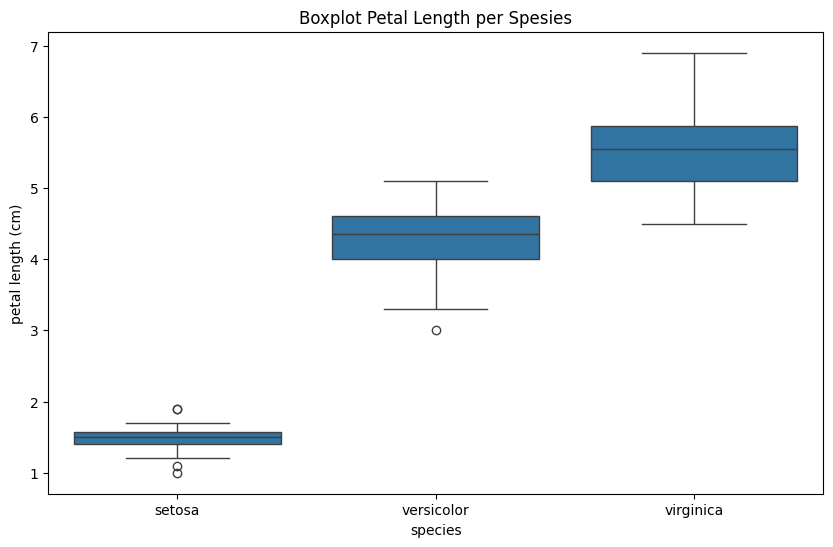

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Boxplot Petal Length per Spesies')
plt.show()

In [6]:
data = df['petal length (cm)'].values
mean_asli = np.mean(data)
median_asli = np.median(data)

mean_asli, median_asli

(np.float64(3.7580000000000005), np.float64(4.35))

In [7]:
np.random.seed(42)

bootstrap_sample = np.random.choice(data, size=len(data), replace=True)

mean_boot = np.mean(bootstrap_sample)
median_boot = np.median(bootstrap_sample)

print("Mean asli        :", mean_asli)
print("Median asli      :", median_asli)
print("Mean bootstrap   :", mean_boot)
print("Median bootstrap :", median_boot)

Mean asli        : 3.7580000000000005
Median asli      : 4.35
Mean bootstrap   : 3.734666666666667
Median bootstrap : 4.2


In [8]:
def bootstrap_means(data, n_bootstrap):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return np.array(means)

means_100 = bootstrap_means(data, 100)
means_1000 = bootstrap_means(data, 1000)
means_10000 = bootstrap_means(data, 10000)

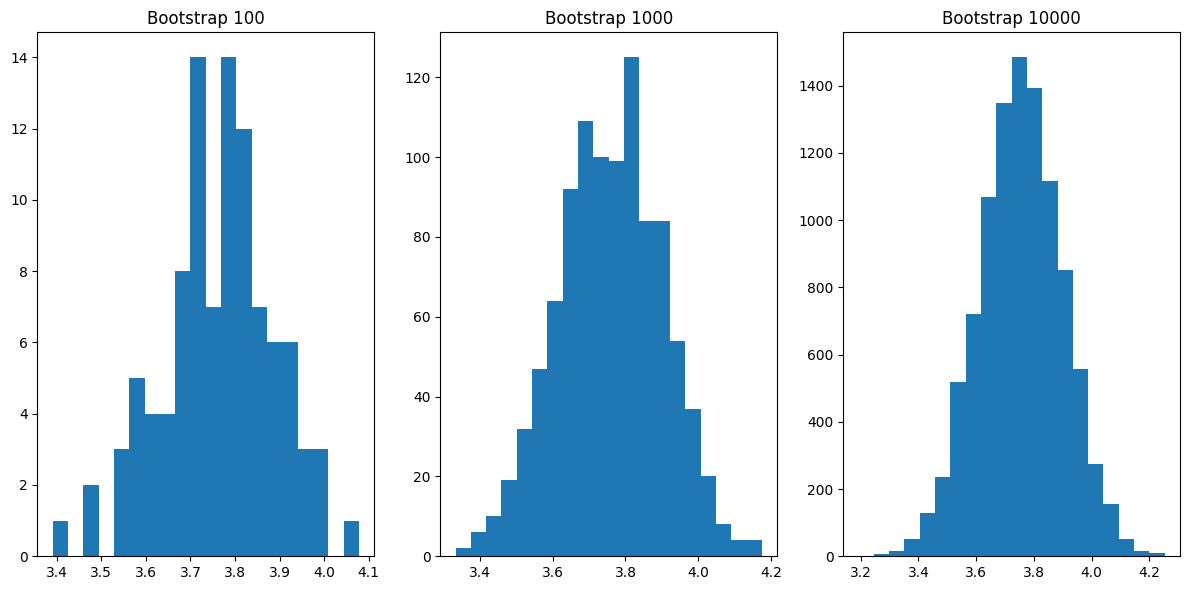

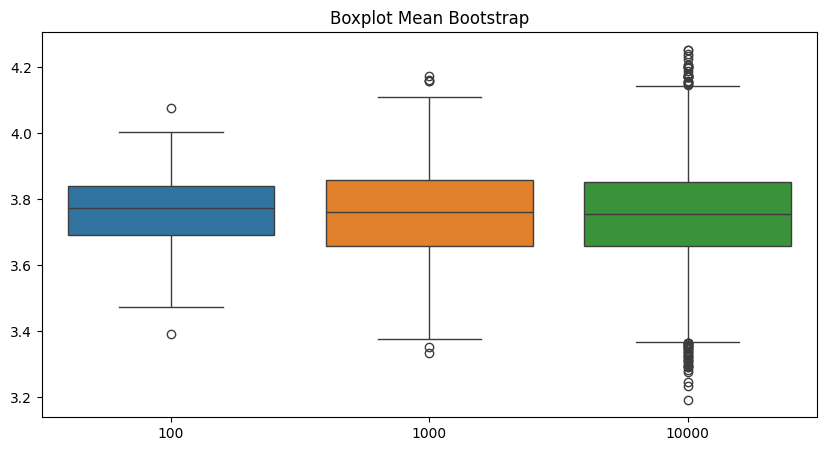

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.hist(means_100, bins=20)
plt.title("Bootstrap 100")

plt.subplot(1, 3, 2)
plt.hist(means_1000, bins=20)
plt.title("Bootstrap 1000")

plt.subplot(1, 3, 3)
plt.hist(means_10000, bins=20)
plt.title("Bootstrap 10000")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=[means_100, means_1000, means_10000])
plt.xticks([0,1,2], ['100', '1000', '10000'])
plt.title("Boxplot Mean Bootstrap")
plt.show()

In [10]:
def ci_95(data_boot):
    return np.percentile(data_boot, [2.5, 97.5])

ci_100 = ci_95(means_100)
ci_1000 = ci_95(means_1000)
ci_10000 = ci_95(means_10000)

print("CI 100    :", ci_100)
print("CI 1000   :", ci_1000)
print("CI 10000  :", ci_10000)
print("Mean asli :", mean_asli)

CI 100    : [3.51233333 3.99135   ]
CI 1000   : [3.47931667 4.02941667]
CI 10000  : [3.46931667 4.03466667]
Mean asli : 3.7580000000000005


Analisis

1. Mean hasil bootstrap nilainya hampir sama dengan mean data asli karena bootstrap diambil dari data yang sama, hanya cara pengambilannya yang diacak.

2. Saat jumlah bootstrap ditambah dari 100 ke 1000 dan 10000, hasil mean terlihat makin rapat dan tidak terlalu menyebar yang artinya hasil perhitungan jadi lebih konsisten.

3. Bootstrap 10000 paling stabil karena variasi nilainya paling kecil dibanding 100 dan 1000.

4. Mean data asli berada di dalam interval kepercayaan 95% yang menunjukkan bahwa hasil bootstrap masih masuk akal dan sesuai dengan data sebenarnya.

5. Satu data bisa muncul berkali-kali karena bootstrap menggunakan pengambilan sampel dengan pengembalian. Jadi satu data bisa terambil lebih dari satu kali dalam satu sampel.

Kesimpulan

Dari hasil EDA, terlihat bahwa dataset Iris memiliki tiga spesies dengan ukuran petal yang berbeda-beda.  
Setosa memiliki ukuran petal paling kecil, Versicolor berada di tengah, dan Virginica paling besar.  

Metode bootstrap membantu melihat sebaran nilai rata-rata dari data tanpa harus menambah data baru.  
Semakin banyak jumlah bootstrap, hasil yang diperoleh semakin stabil.  

Jadi, jumlah bootstrap 1000 sampai 10000 sudah cukup untuk mendapatkan hasil yang lebih konsisten.